In [1]:
import time
notebook_start = time.perf_counter()

%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import os
import pandas as pd
import numpy as np
import feos
import si_units as si
import matplotlib.pyplot as plt
import thermoift.FeosPlugin as TC
import thermoift.semi_emperical_correlations as SEC
import thermoift.PLOT_SETTINGS as ps
from thermoift import KIJ
from pathlib import Path

KIJ_DIR = Path(KIJ.__file__).parent

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=2d45f1c085df1528a9318eff047544413679cad7c2dff8d55aaa40d4a9e5c104
  Stored in directory: /tmp/pip-ephem-wheel-cache-z62lgkck/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.



K(300.0 K) =
[[0.         0.04278669 0.03481295]
 [0.04278669 0.         0.18117968]
 [0.03481295 0.18117968 0.        ]]

Symbolic K(T) matrix:


Matrix([
[     0, 0.0428, 0.0348],
[0.0428,      0, 0.1812],
[0.0348, 0.1812,      0]])


Pair equations:


Eq(k_{CO2,H2}(T), 0.0428)

Eq(k_{CO2,Ar}(T), 0.0348)

Eq(k_{H2,Ar}(T), 0.1812)

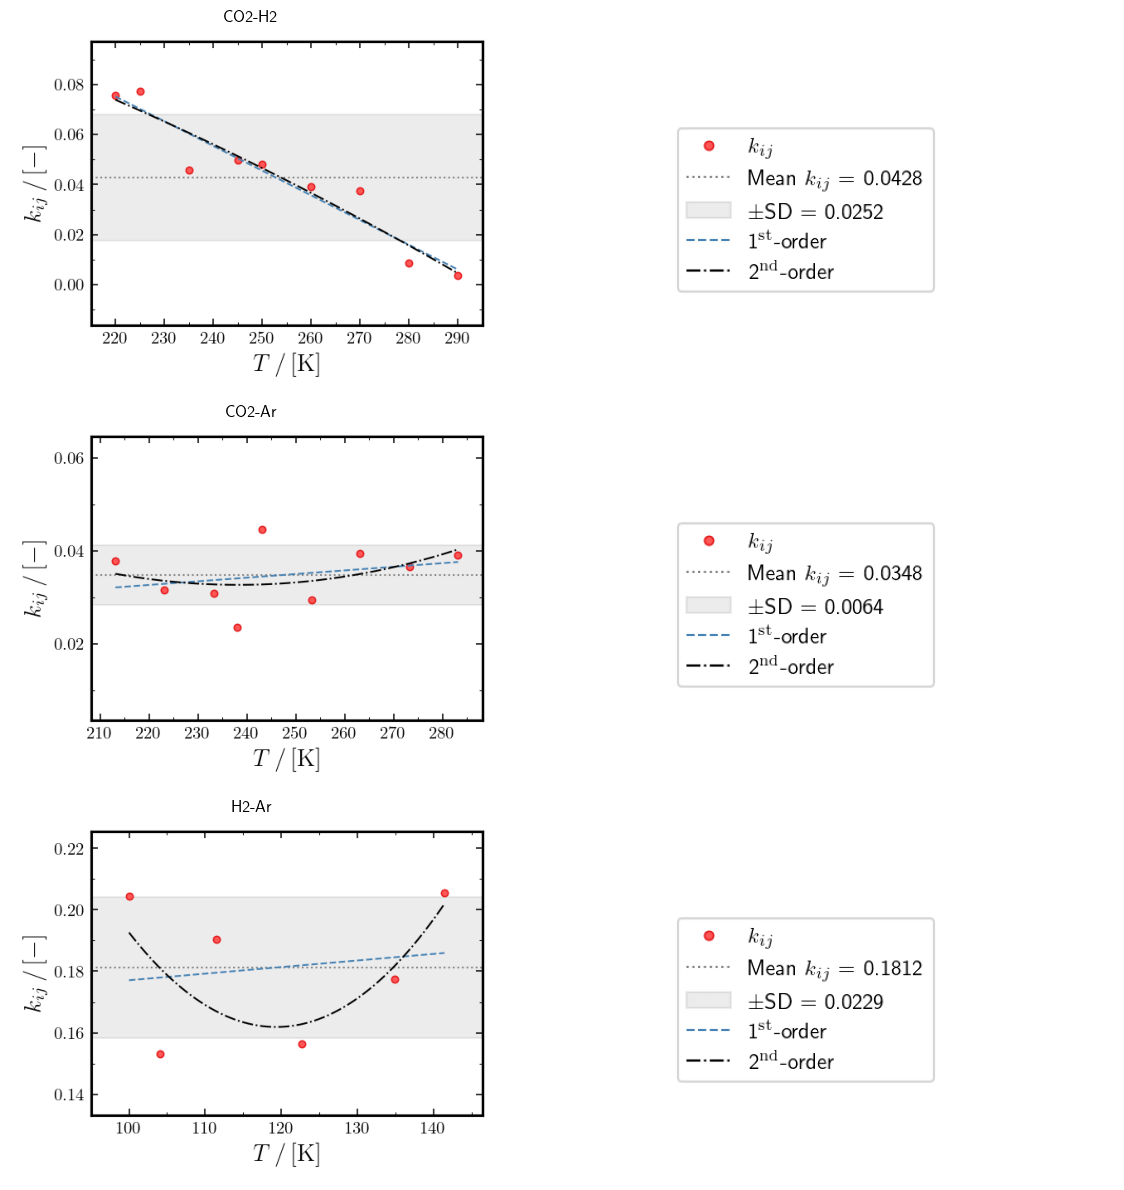

In [2]:
COMPONENT_NAMES = ["carbon dioxide", "hydrogen", "argon"]
ALL_COMPONENTS  = ["carbon dioxide", "hydrogen", "argon", "nitrogen", "methane", "oxygen"]
FEED_Z          = np.array([0.95, 0.02, 0.03], dtype=float)
FEED_Z          = FEED_Z / FEED_Z.sum()

# --- KIJ setup (T-dependent binary interaction parameters) ---
KIJ_map = {
    ("CO2", "Ar") : "constant",
    ("H2",  "Ar") : "constant",
    ("CO2", "H2") : "constant",
}

builder    = KIJ.KIJMatrixBuilder(root=str(KIJ_DIR), kij_filename="KIJ.json", verbose=False)
KIJ_LABELS = TC._kij_labels(COMPONENT_NAMES)

# Display KIJ info
builder.build_and_display(
    components=KIJ_LABELS,
    model_map=KIJ_map,
    T_eval=300.0,
    show_matrix=True,
    show_pair_equations=True,
)

# Show KIJ pair plots
builder.show_pair_plots(KIJ_LABELS, mode="all")

In [3]:
# --- Critical point (use a reference T for kij) ---
T_initial_guess = 200.0
params_ref      = TC.PARAMETERS(COMPONENT_NAMES, T_K=T_initial_guess, kij_builder=builder, model_map=KIJ_map)
eos_ref         = feos.HelmholtzEnergyFunctional.pcsaft(params_ref)
feed_si         = FEED_Z * si.MOL

Tc_si, Pc_si    = TC.VLECalculator.compute_critical_point(eos_ref, FEED_Z, T_guess=T_initial_guess)
Tc_K            = Tc_si / si.KELVIN
Pc_bar          = Pc_si / si.BAR
print(f"Critical Point: T = {Tc_K:.2f} K, P = {Pc_bar:.2f} bar")

# --- Bubble and dew curves with T-dependent kij (rebuild eos per T) ---
T_STEP     = 1  # K
T_values   = range(int(T_initial_guess), int(Tc_K) + 1, T_STEP)

T_bub, P_bub = [], []
T_dew, P_dew = [], []

for T_K_val in T_values:
    params_T = TC.PARAMETERS(COMPONENT_NAMES, T_K=float(T_K_val), kij_builder=builder, model_map=KIJ_map)
    eos_T    = feos.HelmholtzEnergyFunctional.pcsaft(params_T)

    Tb, Pb = TC.VLECalculator.compute_bubble_curve(eos_T, [T_K_val], feed_si, verbose=False)
    Td, Pd = TC.VLECalculator.compute_dew_curve(eos_T,    [T_K_val], feed_si, verbose=False)

    T_bub.extend(Tb); P_bub.extend(Pb)
    T_dew.extend(Td); P_dew.extend(Pd)

print(f"Bubble points: {len(T_bub)}, Dew points: {len(T_dew)}")

Critical Point: T = 305.84 K, P = 92.00 bar
Bubble points: 103, Dew points: 104


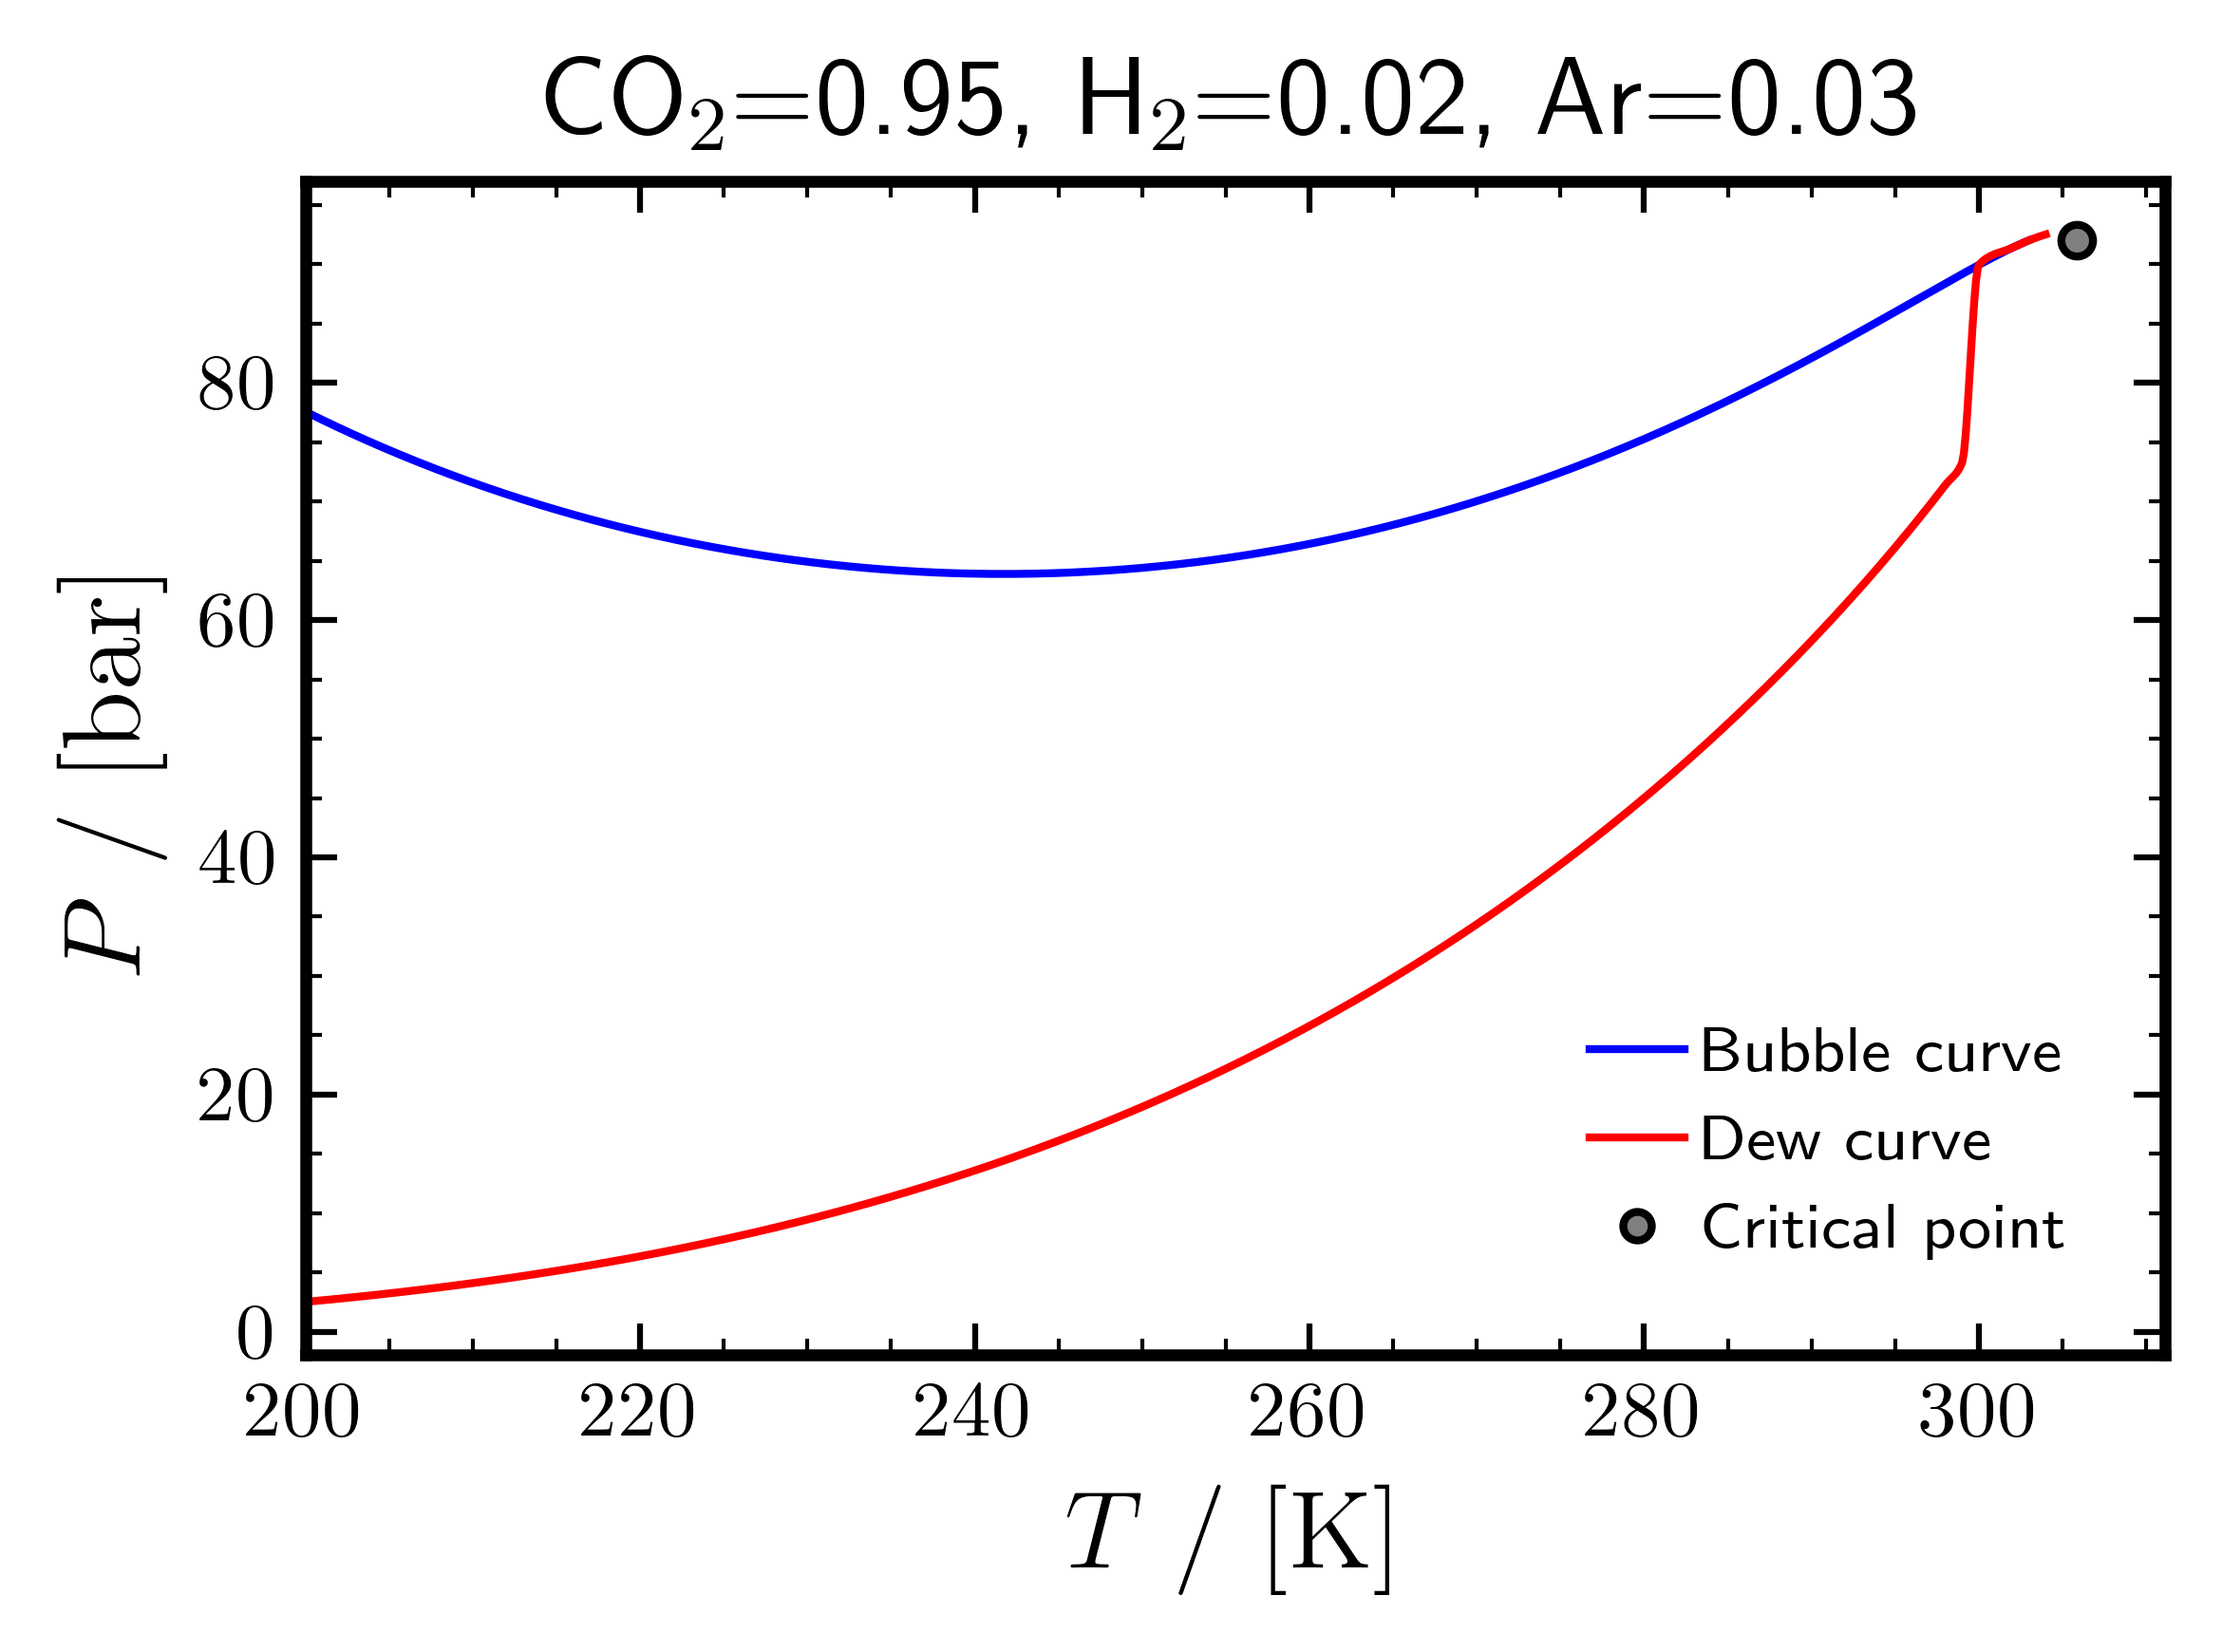

In [4]:
# Build PT_results dict in the format expected by PlottingEngine
feed_key = "feed_0"
PT_results = {
    feed_key: {
        "bubble": [{"T_K": T, "P_bar": P} for T, P in zip(T_bub, P_bub)],
        "dew": [{"T_K": T, "P_bar": P} for T, P in zip(T_dew, P_dew)],
        "TC_K": Tc_K,
        "PC_bar": Pc_bar,
        "z": FEED_Z,
    }
}

# Plot using PlottingEngine (use kij-aware params for labels)
fig, ax = TC.PlottingEngine.plot_phase_diagram(PT_results, feed_key, params_ref)
plt.show()

In [5]:
# --------------------------------------------------------
# Compute IFT along saturation lines (bubble & dew curves)
# --------------------------------------------------------

model       = SEC.semi_emperical_correlations()
N_POINTS    = 50  # Use 50(fast)/500(slow)

# Parachor method
sat_data_parachor = model.compute_saturation_line_IFT(
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    eos=eos_ref,
    T_bub=T_bub,
    P_bub=P_bub,
    T_dew=T_dew,
    P_dew=P_dew,
    method="parachor",
    n_exp=3.87,
    kij_parachor=0.0,
    recompute_parachor=True,
    line="both",
    n_points=N_POINTS,
    P_offset_frac=0.005,
    kij_builder=builder,
    model_map=KIJ_map,
)

# WSD method - computes BOTH corrected and uncorrected in a single pass
sat_data_wsd = model.compute_saturation_line_IFT(
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    eos=eos_ref,
    T_bub=T_bub,
    P_bub=P_bub,
    T_dew=T_dew,
    P_dew=P_dew,
    method="wsd",
    phi_wsd=1.0,
    line="both",
    n_points=N_POINTS,
    P_offset_frac=0.005,
    kij_builder=builder,
    model_map=KIJ_map,
)

df_sat_parachor = SEC.semi_emperical_correlations.saturation_line_to_dataframe(
    sat_data_parachor, COMPONENT_NAMES, line="both")

df_sat_wsd = SEC.semi_emperical_correlations.saturation_line_to_dataframe(
    sat_data_wsd, COMPONENT_NAMES, line="both")

print(f"Parachor DataFrame shape: {df_sat_parachor.shape}")
print(f"WSD DataFrame shape: {df_sat_wsd.shape}")

/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=298.5052857142857 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=300.60114285714286 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=302.697 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve fa

Parachor DataFrame shape: (98, 40)
WSD DataFrame shape: (93, 40)


In [6]:
# -------------------------------------------------------------------------------------------
# Save phase envelope and IFT results to CSV files (separate files per method)
# -------------------------------------------------------------------------------------------
dfs = SEC.semi_emperical_correlations.save_saturation_dataframes(
    df_sat_parachor, df_sat_wsd,
    output_dir="CSV_saturation",
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    n_exp=3.87,  # Parachor exponent
    ML_mode=True,
    all_components=ALL_COMPONENTS,
)

# Unpack for plotting
df_bubble_para = dfs["bubble_parachor"]
df_bubble_wsd = dfs["bubble_wsd"]
df_dew_para = dfs["dew_parachor"]
df_dew_wsd = dfs["dew_wsd"]

print(f"\nBubble Parachor columns: {list(df_bubble_para.columns)}")
print(f"\nBubble WSD columns: {list(df_bubble_wsd.columns)}")

Saved CSV_saturation/bubble_parachor.csv (50 rows, 36 cols)
Saved CSV_saturation/bubble_wsd.csv (47 rows, 42 cols)
Saved CSV_saturation/dew_parachor.csv (48 rows, 36 cols)
Saved CSV_saturation/dew_wsd.csv (46 rows, 42 cols)

Bubble Parachor columns: ['T', 'P', 'z_carbon dioxide', 'z_hydrogen', 'z_argon', 'z_nitrogen', 'z_methane', 'z_oxygen', 'rho_l', 'rho_v', 'x_carbon dioxide', 'x_hydrogen', 'x_argon', 'x_nitrogen', 'x_methane', 'x_oxygen', 'y_carbon dioxide', 'y_hydrogen', 'y_argon', 'y_nitrogen', 'y_methane', 'y_oxygen', 'gamma0_carbon dioxide', 'rhoL0_carbon dioxide', 'rhoV0_carbon dioxide', 'Tc_carbon dioxide', 'Pc_carbon dioxide', 'Psat0_carbon dioxide', 'parachor_carbon dioxide', 'parachor_hydrogen', 'parachor_argon', 'parachor_nitrogen', 'parachor_methane', 'parachor_oxygen', 'n_exp', 'gamma_parachor']

Bubble WSD columns: ['T', 'P', 'z_carbon dioxide', 'z_hydrogen', 'z_argon', 'z_nitrogen', 'z_methane', 'z_oxygen', 'rho_l', 'rho_v', 'x_carbon dioxide', 'x_hydrogen', 'x_argon'

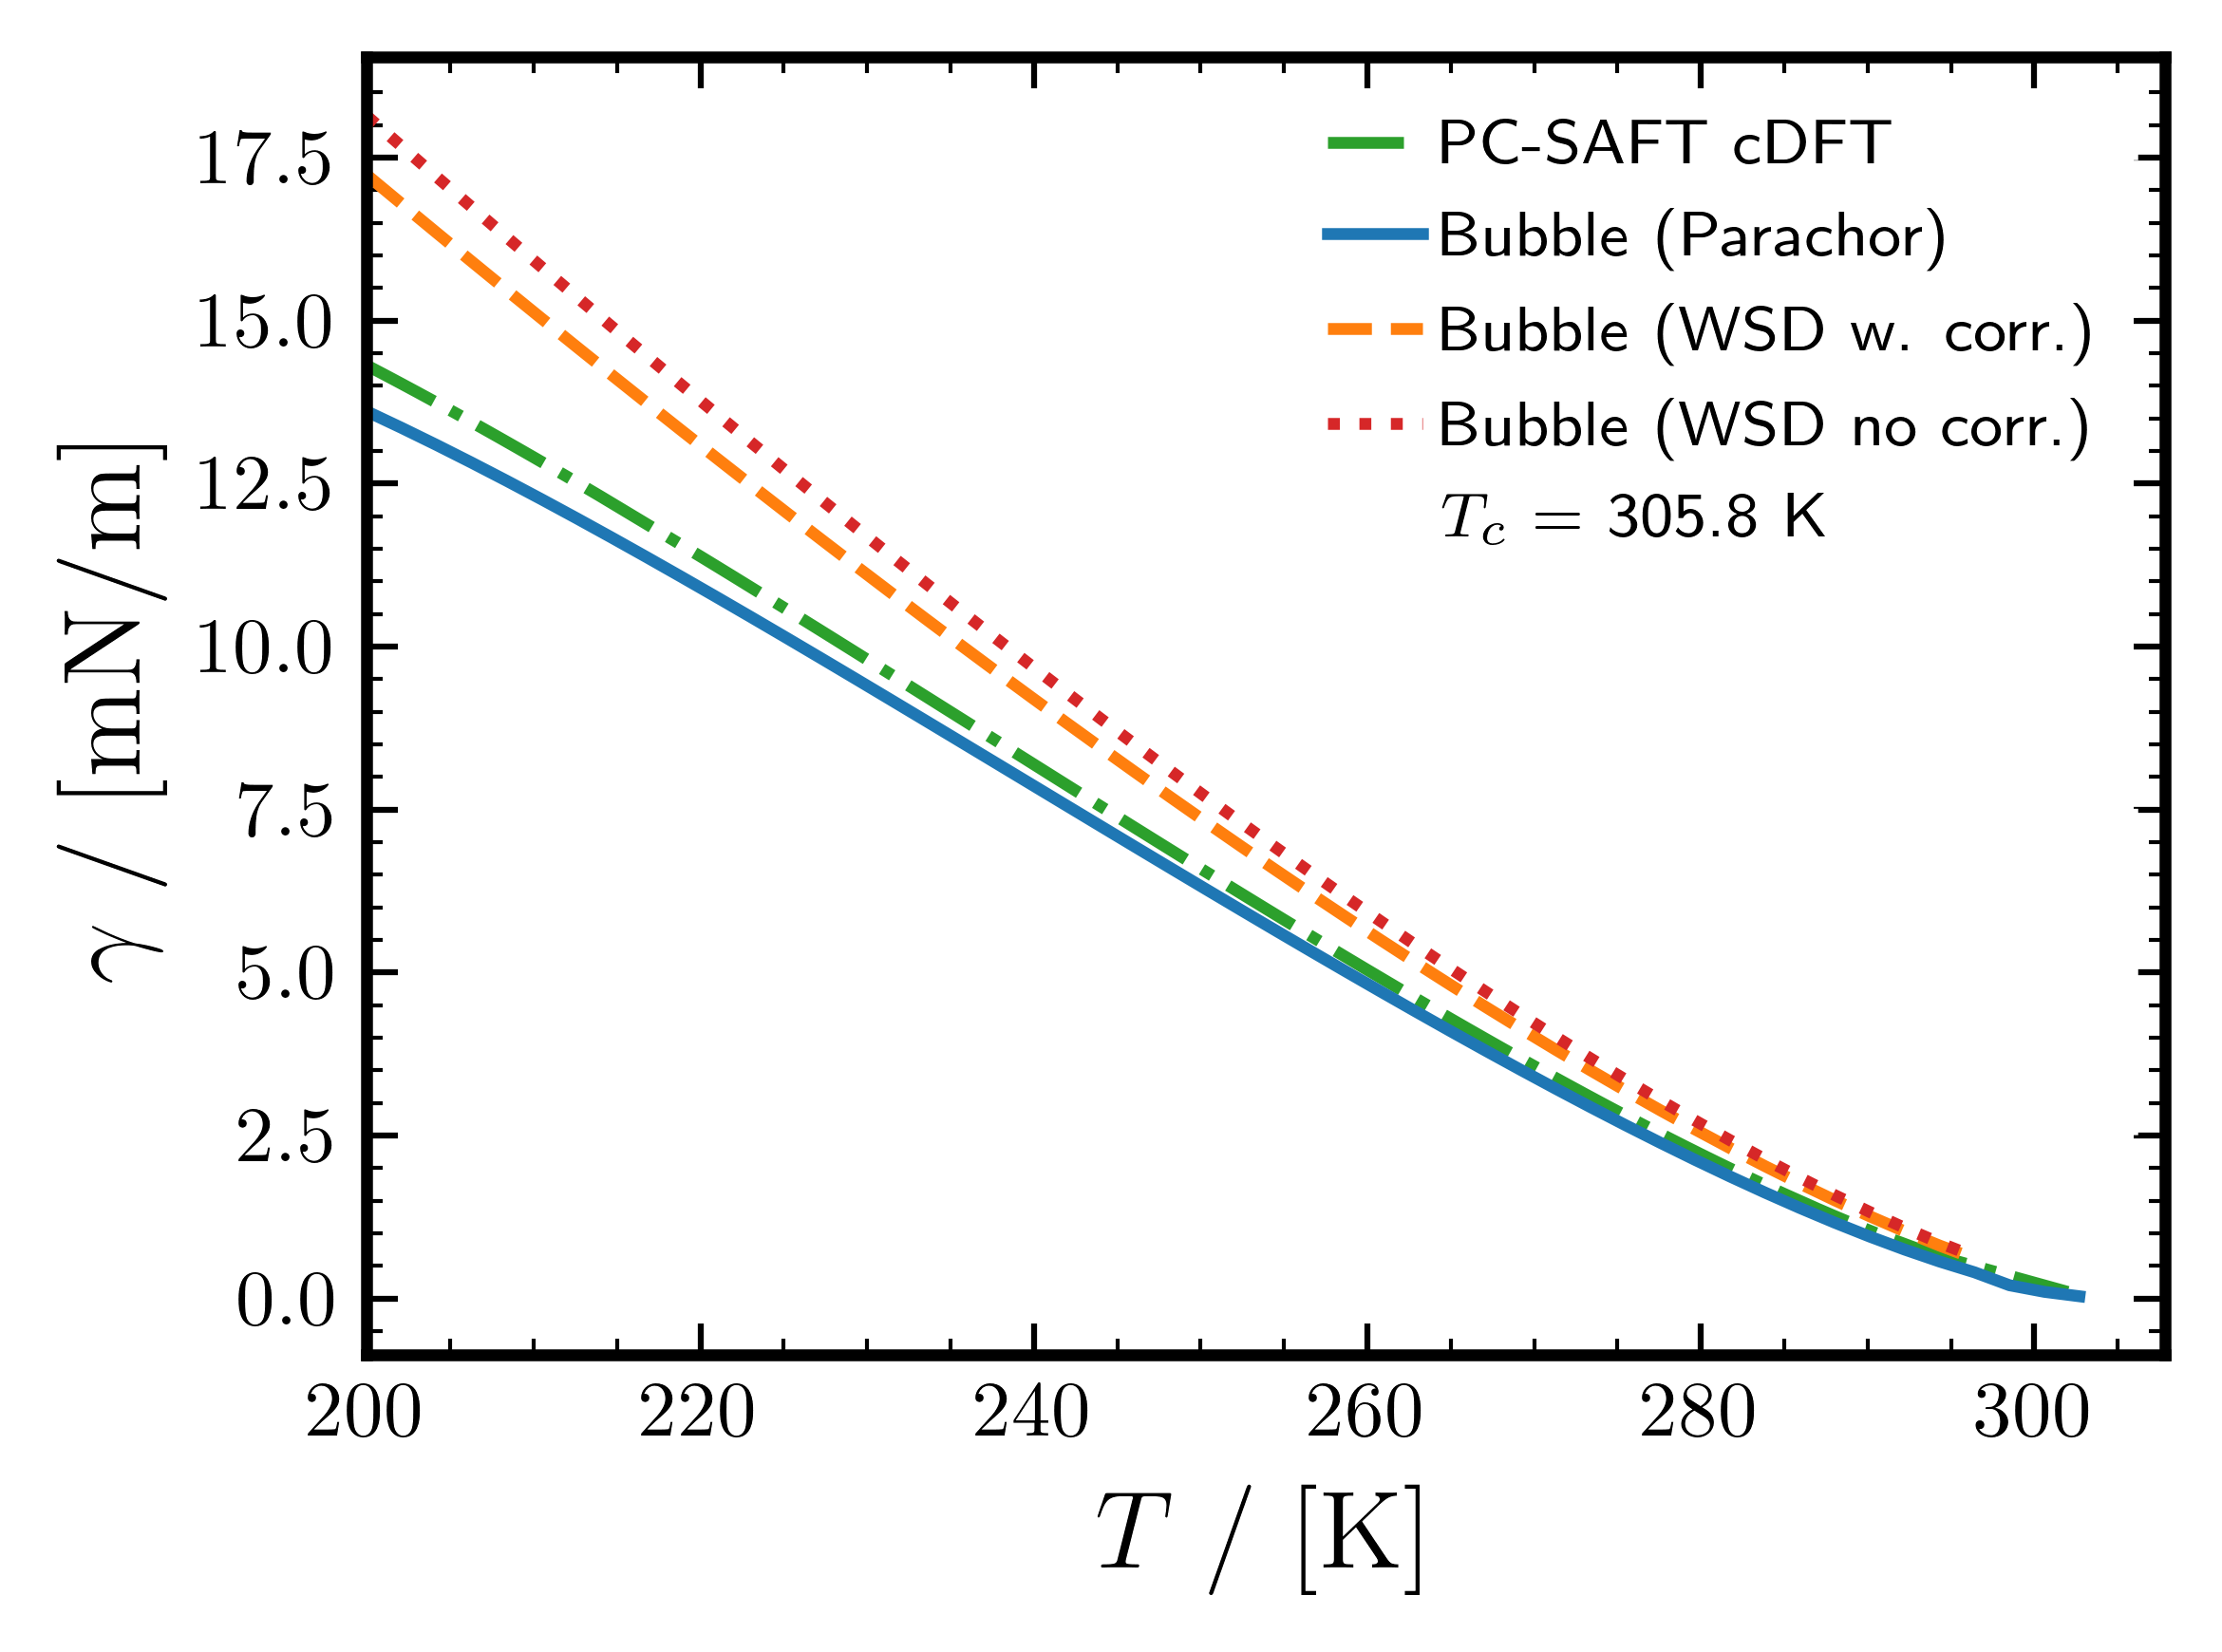

Bubble IFT plot saved to CSV_saturation/bubble_IFT_vs_T.png and CSV_saturation/bubble_IFT_vs_T.pdf


In [7]:
# --- Bubble IFT vs Temperature ---

fig, ax = ps.plot_init()

df_pcsaft = (pd.read_csv("CSV/feed_1_bubble_point_IFT.csv",usecols=["temperature", "gamma"]).dropna(subset=["gamma"]))

# PC-SAFT cDFT
if not df_pcsaft.empty:
    ax.plot(df_pcsaft["temperature"],df_pcsaft["gamma"],label="PC-SAFT cDFT", linestyle="-.", color="C2")

# Parachor
if not df_bubble_para.empty:
    ax.plot(df_bubble_para["T"], df_bubble_para["gamma_parachor"], "-", label="Bubble (Parachor)", color="C0")

# WSD
if not df_bubble_wsd.empty:
    ax.plot(df_bubble_wsd["T"], df_bubble_wsd["gamma_wsd_corrected"], "--", label="Bubble (WSD w. corr.)", color="C1")
    ax.plot(df_bubble_wsd["T"], df_bubble_wsd["gamma_wsd"], ":", label="Bubble (WSD no corr.)", color="C3")

ax.axvline(Tc_K, color="w", linestyle=":", label=f"$T_c$ = {Tc_K:.1f} K")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN/m}]$", fontsize=ps.label_fontsize)
ax.set_xlim(left=200)
ax.minorticks_on()
ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
plt.tight_layout()
plt.savefig("CSV_saturation/bubble_IFT_vs_T.png", dpi=300, bbox_inches="tight")
plt.savefig("CSV_saturation/bubble_IFT_vs_T.pdf", bbox_inches="tight")
plt.show()
print("Bubble IFT plot saved to CSV_saturation/bubble_IFT_vs_T.png and CSV_saturation/bubble_IFT_vs_T.pdf")

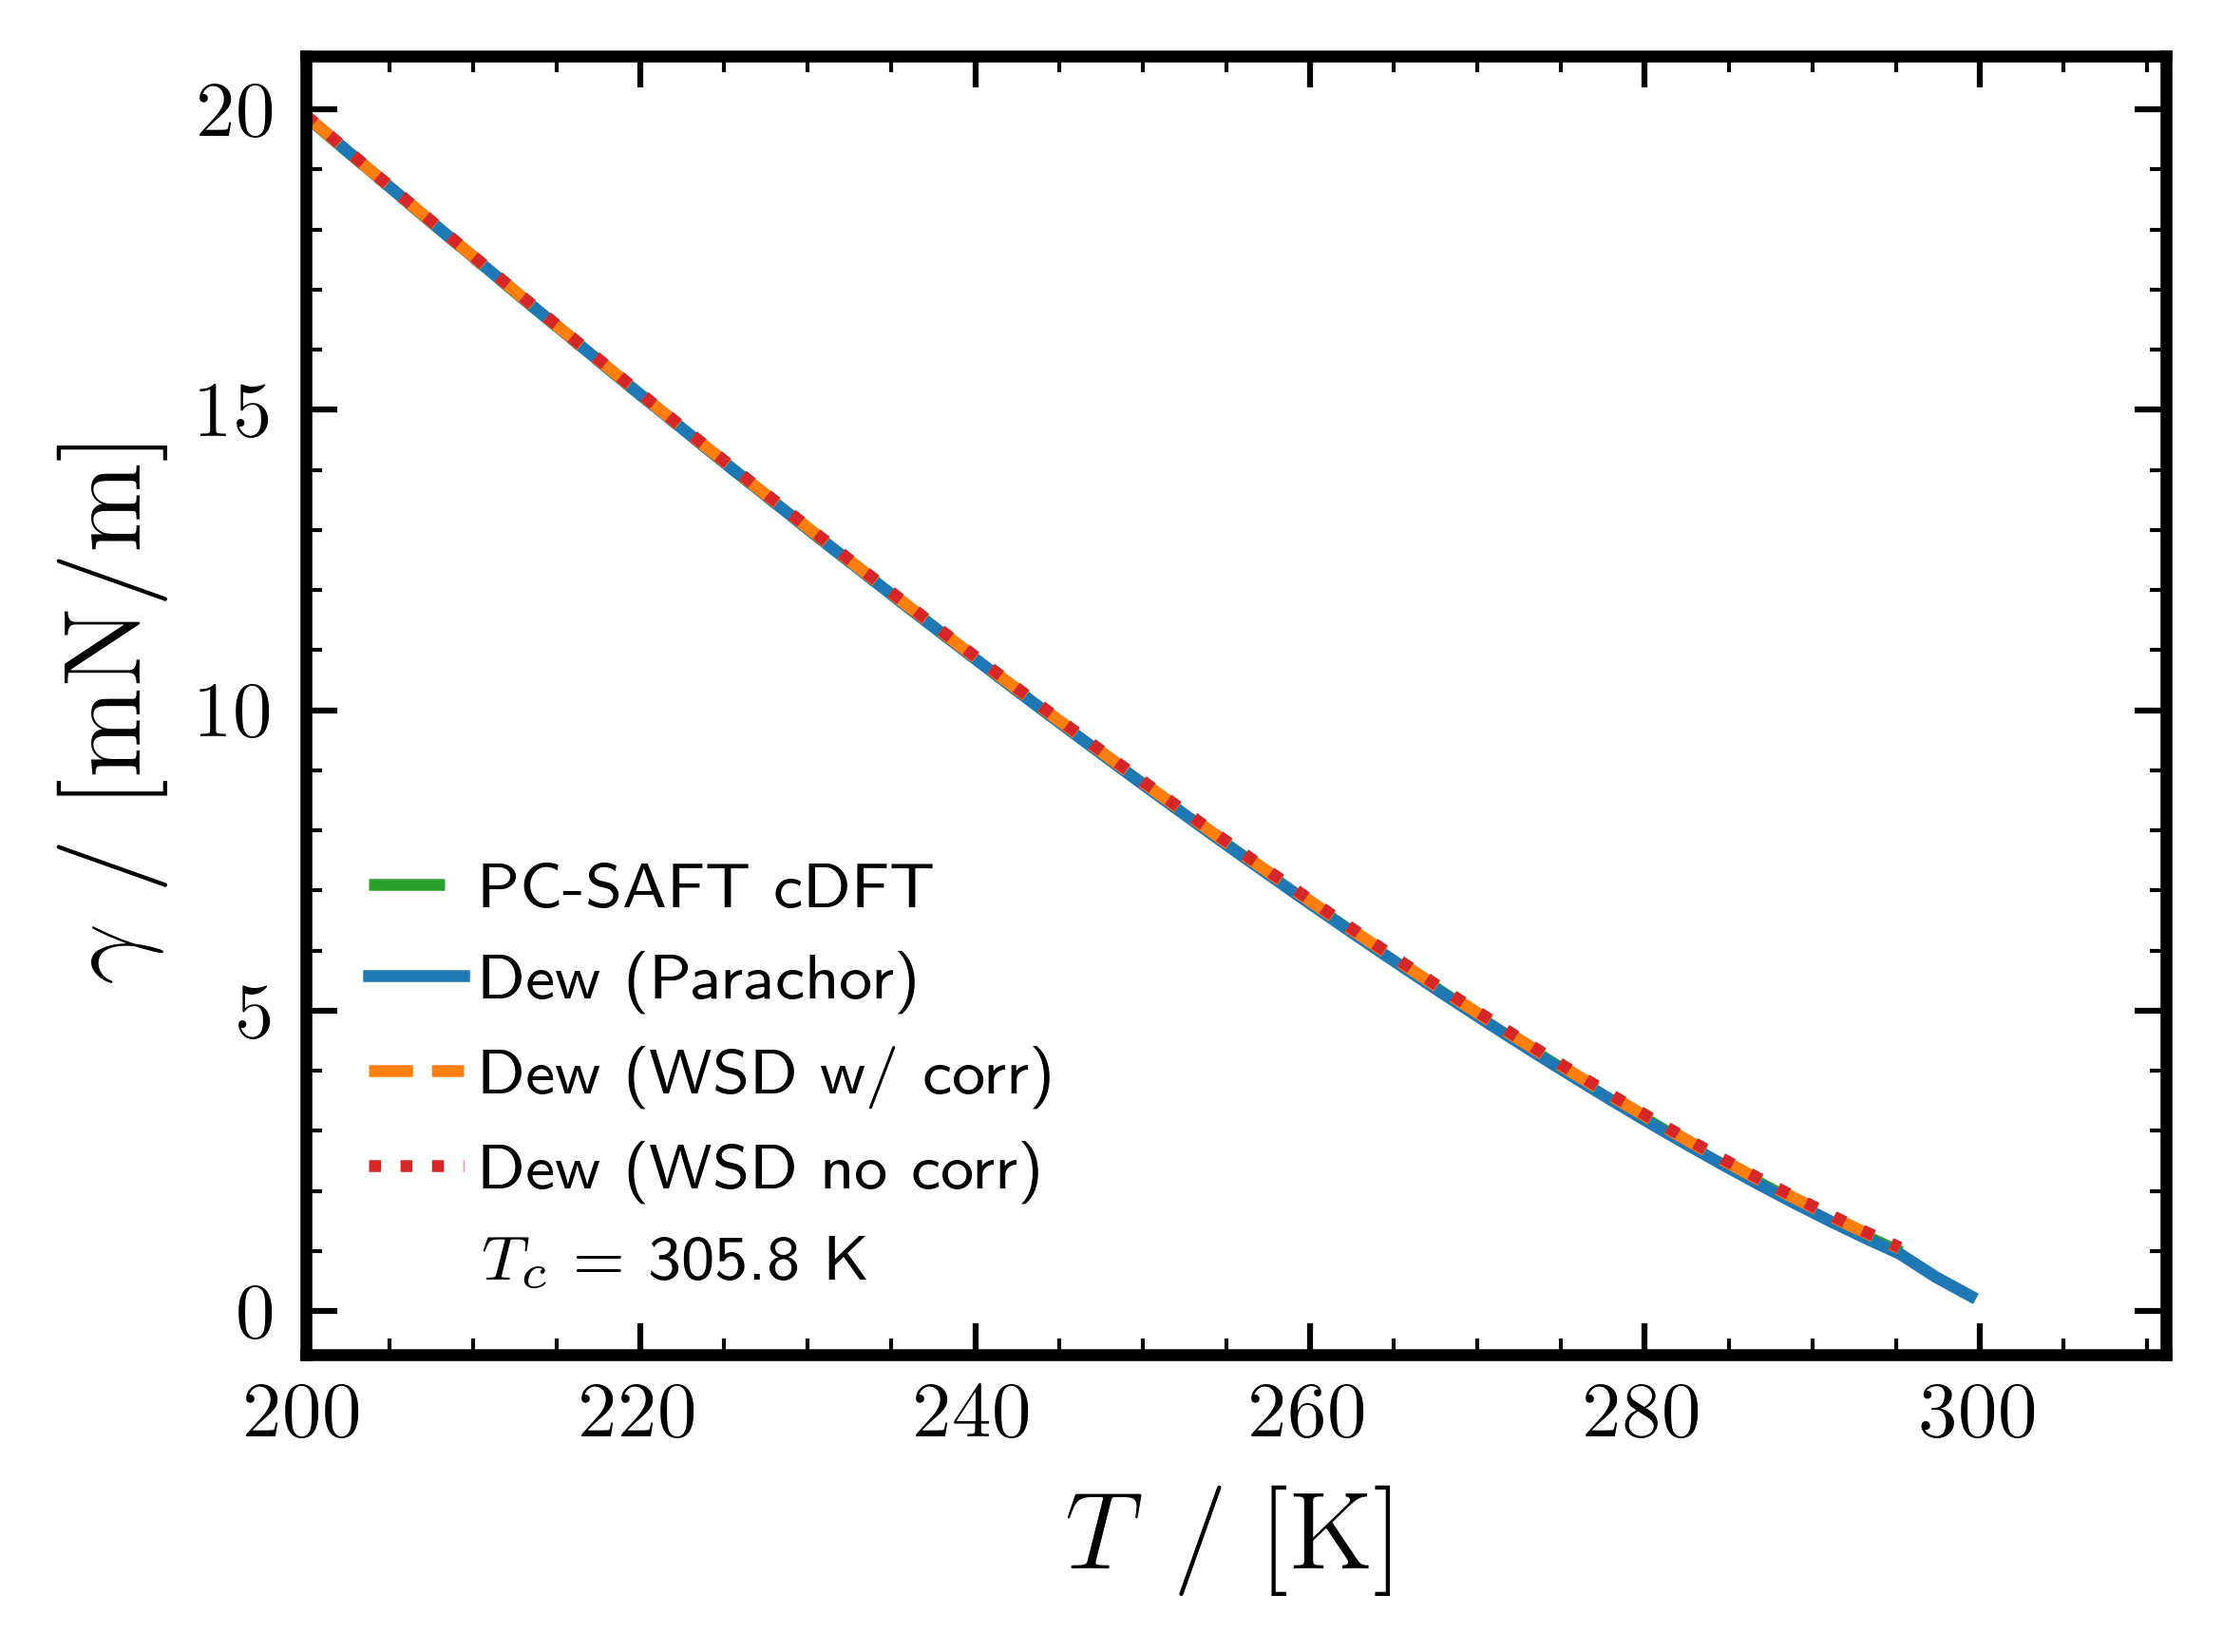

Dew IFT plot saved to CSV_saturation/dew_IFT_vs_T.png and CSV_saturation/dew_IFT_vs_T.pdf


In [8]:
# --- Dew IFT vs Temperature ---

fig, ax = ps.plot_init()

df_pcsaft_dew = (pd.read_csv("CSV/feed_1_dew_point_IFT.csv",usecols=["temperature", "gamma"]).dropna(subset=["temperature", "gamma"]))

# PC-SAFT cDFT
if not df_pcsaft_dew.empty:
    ax.plot(df_pcsaft_dew["temperature"],df_pcsaft_dew["gamma"],label="PC-SAFT cDFT",linestyle="-.",color="C2")

# Parachor
if not df_dew_para.empty:
    ax.plot(df_dew_para["T"], df_dew_para["gamma_parachor"], "-", label="Dew (Parachor)", color="C0")

# WSD
if not df_dew_wsd.empty:
    ax.plot(df_dew_wsd["T"], df_dew_wsd["gamma_wsd_corrected"], "--", label="Dew (WSD w/ corr)", color="C1")
    ax.plot(df_dew_wsd["T"], df_dew_wsd["gamma_wsd"], ":", label="Dew (WSD no corr)", color="C3")

ax.axvline(Tc_K, color="w", linestyle=":", label=f"$T_c$ = {Tc_K:.1f} K")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN/m}]$", fontsize=ps.label_fontsize)
ax.set_xlim(left=200)
ax.minorticks_on()
ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
plt.tight_layout()
plt.savefig("CSV_saturation/dew_IFT_vs_T.png", dpi=300, bbox_inches="tight")
plt.savefig("CSV_saturation/dew_IFT_vs_T.pdf", bbox_inches="tight")
plt.show()
print("Dew IFT plot saved to CSV_saturation/dew_IFT_vs_T.png and CSV_saturation/dew_IFT_vs_T.pdf")

In [9]:
# # --- Plot 2: IFT vs Pressure ---
# if df_sat_parachor.empty and df_sat_wsd.empty:
#     print("No data available - both DataFrames are empty")
# else:
#     fig, ax = ps.plot_init()

#     if bub_para is not None and not bub_para.empty:
#         ax.plot(
#             bub_para["P"], bub_para["gamma_mix"],
#             "-", label="Bubble (Parachor)", color="C0")

#     if bub_wsd is not None and not bub_wsd.empty:
#         ax.plot(
#             bub_wsd["P"], bub_wsd["gamma_mix"],
#             "-", label="Bubble (WSD)", color="C1")

#     ax.axvline(Pc_bar, color="w", linestyle=":", label=f"$P_c$ = {Pc_bar:.1f} bar")
#     ax.set_xlabel(r"$P \; / \; [\mathrm{bar}]$", fontsize=ps.label_fontsize)
#     ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN/m}]$", fontsize=ps.label_fontsize)
#     ax.minorticks_on()
#     ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
#     plt.tight_layout()
#     plt.show()

In [10]:
# # --- Plot 2: IFT vs Pressure ---
# if df_sat_parachor.empty and df_sat_wsd.empty:
#     print("No data available - both DataFrames are empty")
# else:
#     fig, ax = ps.plot_init()

#     if bub_para is not None and not bub_para.empty:
#         ax.plot(
#             bub_para["P"], bub_para["gamma_mix"],
#             "-", label="Bubble (Parachor)", color="C0")

#     if dew_para is not None and not dew_para.empty:
#         ax.plot(
#             dew_para["P"], dew_para["gamma_mix"],
#             "--", label="Dew (Parachor)", color="C0", alpha=0.7)

#     if bub_wsd is not None and not bub_wsd.empty:
#         ax.plot(
#             bub_wsd["P"], bub_wsd["gamma_mix"],
#             "-", label="Bubble (WSD)", color="C1")

#     if dew_wsd is not None and not dew_wsd.empty:
#         ax.plot(
#             dew_wsd["P"], dew_wsd["gamma_mix"],
#             "--", label="Dew (WSD)", color="C1", alpha=0.7)

#     ax.axvline(Pc_bar, color="w", linestyle=":", label=f"$P_c$ = {Pc_bar:.1f} bar")
#     ax.set_xlabel(r"$P \; / \; [\mathrm{bar}]$", fontsize=ps.label_fontsize)
#     ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN/m}]$", fontsize=ps.label_fontsize)
#     ax.minorticks_on()
#     ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
#     plt.tight_layout()
#     plt.show()

In [11]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 0.70 minutes
